# Setup


📝 *Import required libraries and files:*

In [60]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import copy
# Text cleaning & preprocessing
import re
from sklearn.feature_extraction.text import CountVectorizer, ENGLISH_STOP_WORDS
# Dimensionality reduction
from umap import UMAP
from hdbscan import HDBSCAN
# Topic modeling
from bertopic import BERTopic
from sentence_transformers import SentenceTransformer

In [61]:
df = pd.read_parquet("../assets/intermediate_dfs/df_sentiment.parquet") 

# 4.2. - BERTopic modelling

### 4.2.1. - Prepare df for model training

In [62]:
df['word_count'] = df['review_text'].apply(lambda x: len(str(x).split()))
df['word_count'].describe().round(1)

count    653426.0
mean         12.2
std          17.4
min           1.0
25%           2.0
50%           6.0
75%          14.0
max         552.0
Name: word_count, dtype: float64

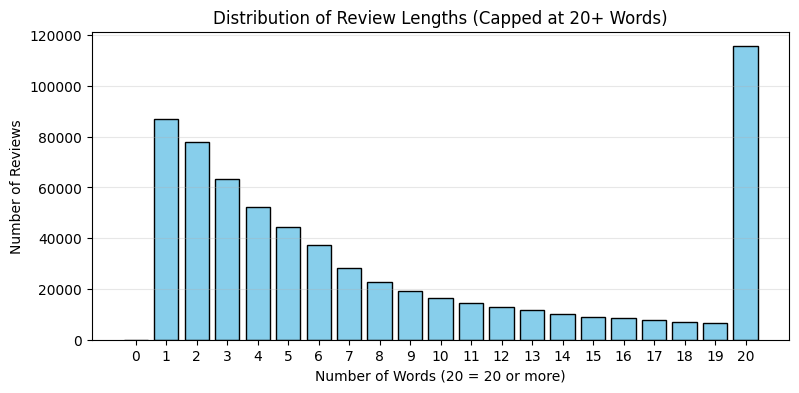

In [63]:
# Calculate number of words per review
df['word_count'] = df['review_text'].apply(lambda x: len(str(x).split()))

# Cap word counts at 20
df['word_count_capped'] = df['word_count'].apply(lambda x: x if x < 20 else 20)

# Count how many reviews per word count
counts = df['word_count_capped'].value_counts().sort_index()

# Ensure we have bins from 0 to 20 (fill missing ones with 0)
counts = counts.reindex(np.arange(0, 21), fill_value=0)

# Plot
plt.figure(figsize=(9, 4))
plt.bar(counts.index, counts.values, color='skyblue', edgecolor='black')
plt.title("Distribution of Review Lengths (Capped at 20+ Words)")
plt.xlabel("Number of Words (20 = 20 or more)")
plt.ylabel("Number of Reviews")
plt.xticks(range(0, 21))
plt.grid(axis='y', alpha=0.3)
plt.show()

In [64]:
print(f"Total reviews: {len(df)}")

# Create a subset of the dataframe with reviews that have at least 4 words and are after October 1, 2021
df_sub1 = df[
    (df['review_text'].str.split().str.len() >= 4) &
    (df['review_date'] > pd.Timestamp('2021-10-01'))
].drop_duplicates(subset=['review_text'], keep='first').copy()

print(f"Total reviews of df_sub1 after filtering: {len(df_sub1)}")

# Create a subset of the dataframe with reviews that have at least 4 words and are before October 1, 2021
df_sub2 = df[
    (df['review_text'].str.split().str.len() >= 4) &
    (df['review_date'] <= pd.Timestamp('2021-10-01'))
].drop_duplicates(subset=['review_text'], keep='first').copy()

print(f"Total reviews of df_sub2 after filtering: {len(df_sub2)}")

Total reviews: 653426
Total reviews of df_sub1 after filtering: 212971
Total reviews of df_sub2 after filtering: 174448


In [65]:
# Setting basic stop words to favor topics related to functionality issues
PRAISE_WORDS = [
    "amazing", "awesome", "brilliant", "excellent", "fantastic", "love", "nice", "perfect", "star", "stars",
    "awful", "bad", "disappointing", "horrible", "poor", "terrible", "useless", "worst", "best"
]

CUSTOM_STOP_WORDS = [
    "santander", "revolut", "revolute", "revoult", "revlout", "revelout", "hsbc", "barclays", 
    "barclay", "lloyds","lloyd", "monzo", "app", "banking", "bank"
]

STOP_WORDS = PRAISE_WORDS + CUSTOM_STOP_WORDS

# BERTopic basic cleaning function
def bertopic_cleaning(df: pd.DataFrame, col: str = "review_text", name="df"):
    if col not in df.columns:
        raise ValueError(f"Column '{col}' not found in DataFrame.")
    
    print(f"Shape of {name} before cleaning: {df.shape}")
    
    df["bert_" + col] = df[col].astype(str) # Create a new column for cleaned text
    cleaned_col = "bert_" + col

    df[cleaned_col] = df[cleaned_col].apply(lambda x: re.sub(r"http\S+", "", str(x))) # Remove URLs
    df[cleaned_col] = df[cleaned_col].apply(lambda x: re.sub(r"\s+", " ", x).strip()) # Normalize spaces

    for w in STOP_WORDS:
        df[cleaned_col] = df[cleaned_col].apply(lambda x: re.sub(rf"\b{re.escape(w)}\b", "", x, flags=re.IGNORECASE)) # Remove stop words

    df[cleaned_col] = df[cleaned_col].apply(lambda x: re.sub(r"\s+", " ", x).strip()) # Normalize spaces again after stop word removal

    # elimnate rows with less than 2 words after cleaning
    df = df[df[cleaned_col].str.split().str.len() >= 2].copy()

    # print number of rows after cleaning
    print(f"Shape of {name} after cleaning: {df.shape}")

    return df

In [66]:
# Perform cleaning on both df_sub1 (recent reviews that will be used for training) and df_sub2 (for later inference)
df_sub1 = bertopic_cleaning(df_sub1, col="review_text", name="df_sub1")
df_sub2 = bertopic_cleaning(df_sub2, col="review_text", name="df_sub2")

Shape of df_sub1 before cleaning: (212971, 22)
Shape of df_sub1 after cleaning: (212700, 23)
Shape of df_sub2 before cleaning: (174448, 22)
Shape of df_sub2 after cleaning: (174210, 23)


In [67]:
df_sub1.head(2)

,ID,app,score,review_text,review_text_clean,review_date,year,thumbs_up,replied,reply_text,...,app_version_head,app_version_detail,review_sentiment,review_sentiment_label,Consistent,reply_sentiment,reply_sentiment_label,word_count,word_count_capped,bert_review_text
0,1,Santander,2,extremely irritating that you can't use an older version of this app. the new version takes up much to space for a banking app,extremely irritating that you can't use an older version of this app. the new version takes up much to space for a banking app,2025-10-20 08:36:34,2025,0,1,Hey there! All feedback is greatly appreciated we will be sure to feed this back to our team. ^HS,...,5,24.0,-0.5095,negative,1,0.7339,positive,24,20,extremely irritating that you can't use an older version of this . the new version takes up much to space for a
2,3,Santander,4,"Please stop forcing us to update the app. This happens far too often and is annoying. Quickly check your balance? No, impossible until you've wasted time downloading and then installing an unwanted upgrade.","please stop forcing us to update the app. this happens far too often and is annoying. quickly check your balance? no, impossible until you've wasted time downloading and then installing an unwanted upgrade.",2025-10-19 16:10:13,2025,0,1,"Hi Michael, sorry to hear you're having issues with this. We need to update the app to stay on top of security and keep your accounts safe. ^WB",...,5,27.0,-0.7717,negative,1,0.7003,positive,33,20,"Please stop forcing us to update the . This happens far too often and is annoying. Quickly check your balance? No, impossible until you've wasted time downloading and then installing an unwanted upgrade."


In [68]:
# Pre-calculate embeddings
embedding_model = SentenceTransformer("all-MiniLM-L6-v2")

embeddings_sub1 = embedding_model.encode(
    df_sub1["bert_review_text"].to_list(), 
    show_progress_bar=True,
    convert_to_numpy=True,
    normalize_embeddings=True
)

embeddings_sub2 = embedding_model.encode(
    df_sub2["bert_review_text"].to_list(), 
    show_progress_bar=True,
    convert_to_numpy=True,
    normalize_embeddings=True
)

Batches:   0%|          | 0/6647 [00:00<?, ?it/s]

Batches:   0%|          | 0/5445 [00:00<?, ?it/s]

In [69]:
# Create directory one level up from the notebook folder
os.makedirs("../assets/models/bertopic", exist_ok=True)

# Save the files
np.save("../assets/models/bertopic/embeddings_sub1_miniLM_L6.npy", embeddings_sub1)
np.save("../assets/models/bertopic/embeddings_sub2_miniLM_L6.npy", embeddings_sub2)

## 4.2.2. - Unseeded topic modelling

### 4.2.2.1. - Model Training

In [11]:
# Load embeddings
embeddings_sub1 = np.load("../assets/models/bertopic/embeddings_sub1_miniLM_L6.npy")

In [12]:
# Dimensionality reduction tuned for short reviews
umap_model = UMAP(
    n_neighbors=30,           # lower values (5-10) --> more, smaller and tighter clusters; higher values (50-100) --> fewer, larger clusters
    n_components=5,           # number of dimensions to reduce embeddings before clustering. For app reviews 5 tends to be standard
    min_dist=0.0,             # controls how tight we want the clustering to be. 0.0 is recommended for BERTopic --> HDBSCAN works better with tightly packed clusters
    metric="cosine",          # cosine distance is best for text embeddings
    random_state=42)          # ensure reproducibility

# Clustering tuned for short reviews
hdbscan_model = HDBSCAN(
    min_cluster_size=150,      # minimum number of documents required to form a cluster
    cluster_selection_epsilon=0.3,    # Merge clusters within 0.3 distance
    min_samples=None,         # if None, min_samples = min_cluster_size
    metric="euclidean",       # recomended for BERTopic
    cluster_selection_method="eom", 
    prediction_data=True)

# Vectorizer 
STOP_WORDS = PRAISE_WORDS + CUSTOM_STOP_WORDS + list(ENGLISH_STOP_WORDS)
vectorizer_model = CountVectorizer(
    stop_words= STOP_WORDS,
    ngram_range=(1, 2),       # unigrams and bigrams  
    min_df=10,                 # ignores terms appearing in less than 'n' documents
    max_df=0.5                # ignores terms appearing in more than 'x%' of documents
)

# Create the BERTopic model
unseed_topic_model = BERTopic(
    vectorizer_model=vectorizer_model,
    umap_model=umap_model,
    hdbscan_model=hdbscan_model,
    language="english",             
    calculate_probabilities=True,   
    verbose=True)

In [13]:
topics, probs = unseed_topic_model.fit_transform(df_sub1["bert_review_text"].to_list(), embeddings_sub1)

2025-10-29 21:37:40,705 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2025-10-29 21:44:16,305 - BERTopic - Dimensionality - Completed ✓
2025-10-29 21:44:16,338 - BERTopic - Cluster - Start clustering the reduced embeddings
2025-10-29 21:49:50,404 - BERTopic - Cluster - Completed ✓
2025-10-29 21:49:50,527 - BERTopic - Representation - Fine-tuning topics using representation models.
2025-10-29 21:49:56,154 - BERTopic - Representation - Completed ✓


In [14]:
# Save Bertopic model 
unseed_topic_model.save("../assets/models/bertopic/unseed_model")

2025-10-29 21:49:57,315 - BERTopic - WARNING: When you use `pickle` to save/load a BERTopic model,please make sure that the environments in which you saveand load the model are **exactly** the same. The version of BERTopic,its dependencies, and python need to remain the same.


### 4.2.2.2. - Model evaluation and finetune

In [15]:
unseed_topic_model = BERTopic.load("../assets/models/bertopic/unseed_model")

In [16]:
unseed_topic_model.get_topic_info()

,Topic,Count,Name,Representation,Representative_Docs
0,-1,33235,-1_accounts_credit_payments_banks,"[accounts, credit, payments, banks, payment, c...",[Good in general. I the feature showing the ba...
1,0,79320,0_payments_payment_exchange_crypto,"[payments, payment, exchange, crypto, transfer...",[Very handy during travelling when need to exc...
2,1,22081,1_use works_use does_use helpful_need easy,"[use works, use does, use helpful, need easy, ...","[Straight forward to use so helpful to me, Ver..."
3,2,8774,2_secure easy_use secure_reliable easy_safe easy,"[secure easy, use secure, reliable easy, safe ...","[Safe and secure, easy to navigate., Safe and ..."
4,3,8567,3_good far_good like_great good_good thanks,"[good far, good like, great good, good thanks,...","[Good I like it., Been Good so far, good so far]"
...,...,...,...,...,...
59,58,167,58_options easy_use options_lots options_optio...,"[options easy, use options, lots options, opti...","[Many options and easy to use., many options, ..."
60,59,163,59_use functional_functional easy_fluid_functi...,"[use functional, functional easy, fluid, funct...","[Easy to use and very functional., really easy..."
61,60,161,60_2024_2025_2022_2023,"[2024, 2025, 2022, 2023, 2020, march, june, 20...",[A very good . Not been disappointed to date. ...
62,61,158,61_banks_change banks_changing banks_switch,"[banks, change banks, changing banks, switch, ...",[Changing phone trying to put on new phone it ...


In [17]:
# create a new vectorizer with English stop words
GENERAL_WORDS = ["app", "bank", "banking", "great","use","very","easy","extremelly", "get","like","love","good","time","work",
                 "well","new","best","nice","better", "one","make","also","see","want","need","always","much",
                 "still","way","even","look","really","thank","thanks", 'able', 'absolutely', 'accounts', 'add', 'ago', 'alot', 
                 'allows', 'amazing', 'anymore', 'appropriate','awesome', 'bad', 'banking', 'best', 'better', 'bit', 'branch', 
                 'brilliant', 'business', 'change', 'cheque', 'cheques','clear', 'close', 'complicated', 
                 'convenient', 'constantly', 'daily', 'date', 'day', 'days', 'definitely', 'did', 'didnt', 'different', 'difficult', 'does', 
                 'doesnt', 'doing', 'dont', 'ease', 'easier', 'easily', 'easy', 'effective', 'efficient', 'especially', 'exactly', 'excellent', 
                 'experience', 'extremely', 'fab', 'fantastic', 'far', 'fast', 'feels','finances', 'fine', 'fix', 'follow', 'forward', 'getting', 
                 'gives', 'going', 'good', 'google', 'got', 'great', 'guys', 'handy', 'happy', 'havent', 'having', 'hassle', 'hello', 'helpful', 
                 'helps', 'highly', 'hope', 'hoping', 'improved', 'isnt', 'issues', 'job', 'just','keeping', 'keeps', 'know', 'latest', 'let', 
                 'lets', 'life', 'like', 'little', 'live', 'long', 'longer', 'lot', 'lots', 'love', 'loving','make', 'makes', 'making', 'month', 
                 'months', 'need', 'needed', 'needs', 'neo', 'new', 'nice', 'number', 'old', 'online','open', 'overall', 'payees', 'pending', 
                 'people', 'perfect', 'perfectly', 'place', 'pleased', 'poor', 'pretty', 'quick', 'quickly', 'quite', 'really', 'reason', 
                 'recommend', 'recommended', 'reliable', 'rooted', 'round', 'rubbish', 'safe', 'satisfied', 'saves', 'say', 'says', 'set', 
                 'simple', 'simpler', 'simply', 'slow', 'smooth', 'sort', 'star', 'stars', 'stopped', 'straighforward', 'straight', 
                 'straightforward', 'stuff', 'super', 'superb', 'sure', 'takes', 'team', 'terrible', 'thank', 'thats', 'think', 'thing', 
                 'things', 'time', 'times', 'tin', 'tried', 'try', 'trying', 'unable', 'understand', 'use', 'used', 'useful', 'useless', 
                 'using', 'usually', 'want', 'way', 'website', 'went', 'whats', 'wish', 'wonderful', 'wont', 'work', 'worked', 'working', 'works', 
                 'worst', 'wrong', 'years']
NEW_STOP_WORDS = STOP_WORDS + GENERAL_WORDS

new_vectorizer = CountVectorizer(stop_words= NEW_STOP_WORDS , min_df=2, ngram_range=(1, 2))

# update BERTopic’s internal vectorizer
unseed_topic_model.update_topics(
    df_sub1["bert_review_text"].to_list(),                     
    vectorizer_model=new_vectorizer,
    representation_model=None   
)

In [18]:
unseed_topic_model.get_topic_info()

,Topic,Count,Name,Representation,Representative_Docs
0,-1,33235,-1_account_money_phone_im,"[account, money, phone, im, ive, credit, acces...",[Good in general. I the feature showing the ba...
1,0,79320,0_money_card_account_update,"[money, card, account, update, transfer, log, ...",[Very handy during travelling when need to exc...
2,1,22081,1_problems_problem_ive_problems problems,"[problems, problem, ive, problems problems, co...","[Straight forward to use so helpful to me, Ver..."
3,2,8774,2_secure_security_secure secure_secure security,"[secure, security, secure secure, secure secur...","[Safe and secure, easy to navigate., Safe and ..."
4,3,8567,3_ok_im_enjoying_lovely,"[ok, im, enjoying, lovely, cool, seen, world, ...","[Good I like it., Been Good so far, good so far]"
...,...,...,...,...,...
59,58,167,58_options_options options_available options_o...,"[options, options options, available options, ...","[Many options and easy to use., many options, ..."
60,59,163,59_functional_functional functional_fluid_func...,"[functional, functional functional, fluid, fun...","[Easy to use and very functional., really easy..."
61,60,161,60_2024_2025_2022_2023,"[2024, 2025, 2022, 2023, 2020, march, june, 20...",[A very good . Not been disappointed to date. ...
62,61,158,61_banks_switch banks_changing banks_switch,"[banks, switch banks, changing banks, switch, ...",[Changing phone trying to put on new phone it ...


In [19]:
# Visualize topics as a hierarchical tree
fig = unseed_topic_model.visualize_hierarchy()
fig.show()

In [20]:
# keep original untouched
unseed_try = copy.deepcopy(unseed_topic_model)

In [21]:
# reduce the number of topics
unseed_try.reduce_topics(df_sub1["bert_review_text"].to_list(), nr_topics=25)

2025-10-29 21:51:11,975 - BERTopic - Topic reduction - Reducing number of topics
2025-10-29 21:51:12,182 - BERTopic - Representation - Fine-tuning topics using representation models.
2025-10-29 21:51:16,909 - BERTopic - Representation - Completed ✓
2025-10-29 21:51:16,922 - BERTopic - Topic reduction - Reduced number of topics from 64 to 25


Exploration of the reduced set of topics

In [22]:
unseed_try.get_topic_info()

,Topic,Count,Name,Representation,Representative_Docs
0,-1,33235,-1_account_money_phone_im,"[account, money, phone, im, ive, card, transfe...",[very good website. extremely user friendly. g...
1,0,91221,0_account_money_card_update,"[account, money, card, update, pay, transfer, ...",[always quick and easy to transfer money to ot...
2,1,63424,1_service_secure_navigate_friendly,"[service, secure, navigate, friendly, problems...","[better than any other service., Easy to use a..."
3,2,10542,2_im_ok_lovely_enjoying,"[im, ok, lovely, enjoying, cool, ive, moment, ...","[all ok. easy enough., Ok... But could do bett..."
4,3,2463,3_chat_statements_support_help,"[chat, statements, support, help, download, me...","[and the 'live chat' is absolutely ., chat is ..."
5,4,1643,4_notifications_notification_push_push notific...,"[notifications, notification, push, push notif...","[good until notifications stopped otherwise, R..."
6,5,1590,5_concise_information_clearer_friendly,"[concise, information, clearer, friendly, user...",[Works well every time I use it. Clear and con...
7,6,1203,6_la_que_si_en,"[la, que, si, en, el, es, et, se, nu, una]",[Es el medio de pago con el que menos sorpresa...
8,7,1015,7_review_rating_rate_asking,"[review, rating, rate, asking, reviews, asking...",[great. I give 5 and I like . if something hap...
9,8,984,8_branches_local_closed_visit,"[branches, local, closed, visit, closing, staf...",[Makes it so easy to do now tiara are very few...


In [23]:
# Visualize topics as a hierarchical tree
fig = unseed_try.visualize_hierarchy()
fig.show()

In [24]:
unseed_try.visualize_barchart(width = 280, height = 330, top_n_topics=15, n_words=10)

The unseeded model, even before the reduction, created significant concentration of reviews in one dominant topic - topic 0. After reduction, both topic 0 and topic 1 clearly dominate, absorbing a huge proportion of reviews, which diminishes the insights given by this model so far. Let's examinate the main dominant topic to see if we can extract something more from there.

In [25]:
# further analysis on dominant topic
dominant_topic = 0 
big_topic_docs = [df_sub1["bert_review_text"].to_list()[i] for i, t in enumerate(topics) if t == dominant_topic]

In [26]:
big_topic_embs = np.array([embeddings_sub1[i] for i, t in enumerate(topics) if t == dominant_topic])

In [27]:
# Smaller, more local neighborhood = finer clusters
umap_model = UMAP(
    n_neighbors=15,       # fewer neighbors → more detailed clusters
    n_components=10,      # 5–15 usually works well
    min_dist=0.0,
    metric="cosine"
)

# Allow smaller topic sizes than before
hdbscan_model = HDBSCAN(
    min_cluster_size=1000, 
    min_samples=10,
    metric='euclidean',
    cluster_selection_method='eom',
    prediction_data=True
)

subtopic_model = BERTopic(
    umap_model=umap_model,
    hdbscan_model=hdbscan_model,
    calculate_probabilities=True,
    verbose=True
)

In [28]:
sub_topics, sub_probs = subtopic_model.fit_transform(big_topic_docs, big_topic_embs)

2025-10-29 21:56:42,539 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2025-10-29 21:57:31,448 - BERTopic - Dimensionality - Completed ✓
2025-10-29 21:57:31,473 - BERTopic - Cluster - Start clustering the reduced embeddings
2025-10-29 21:58:03,238 - BERTopic - Cluster - Completed ✓
2025-10-29 21:58:03,265 - BERTopic - Representation - Fine-tuning topics using representation models.
2025-10-29 21:58:05,005 - BERTopic - Representation - Completed ✓


In [29]:
subtopic_model.get_topic_info()

,Topic,Count,Name,Representation,Representative_Docs
0,-1,402,-1_receipt_screenshot_to_screenshots,"[receipt, screenshot, to, screenshots, payment...","[Not a , but please can you work on **proof of..."
1,0,37157,0_the_to_and_it,"[the, to, and, it, my, is, not, account, this,...",[Just did the update was working and once agai...
2,1,20739,1_to_and_easy_the,"[to, and, easy, the, money, it, use, for, is, ...","[and easy to transfer money, Very easy to use...."
3,2,9009,2_for_and_exchange_to,"[for, and, exchange, to, great, easy, currency...",[this for travelling you get the exchange rate...
4,3,7518,3_card_the_to_and,"[card, the, to, and, my, for, it, is, use, you]","[I it card easy to use, can't add money to car..."
5,4,2856,4_crypto_and_for_to,"[crypto, and, for, to, the, is, stocks, tradin...","[Great for crypto, Easy to use. Great for cryp..."
6,5,1639,5_balance_the_widget_to,"[balance, the, widget, to, is, it, and, see, q...",[The latest update to the balance widget made ...


As it can be seen, the unseeded model continues to show a propensity to create big cluster of reviews, even after trying to create a subtopic_model on top of the dominant topic. We could do some additional finetune to 'force' the creation of smaller clusters. However, since we already know which type of issues/topics are we dealing with, we will try a different modelling approach using a seeded list and check if we get better results.

## 4.2.3. -  Seeded Topic Modeling

#### 4.2.3.1. - Model Training

In [70]:
seed_topic_list = [
    ["service", "customer service", "support", "customer support", "chat", "help", "problem", "contact", "assistance", "agent", "answer"], # customer support
    ["safe", "unsafe", "safety", "fingerprint", "authentication", "auth", "reliable"], # security & authentication
    ["login", "access", "fingerprint", "password", "pass", "log", "sign in", "locked", "access denied", "session"], # login
    ["payments", "pay", "transactions", "transfers", "send money"], # payments & transfers
    ["quick", "slow", "performance", "crashes", "bug", "speed", "error", "lag", "freeze", "responsive"], # performance
    ["pretty", "layout", "navigation", "interface", "design", "menu", "scroll"], # navigation & layout
    ["simple", "easy to use", "complex", "convenient", "experience", "intuitive", "complicated"], # simplicity
    ["price", "free", "rates", "cheap", "expensive", "cost"], # price
    ["card", "card lost", "credit card", "debit", "contactless"], # cards
    ["feature", "investments", "crypto", "cashback", "option", "settings", "preferences"], # features
    ["manage", "balance", "money management", "track", "expenses", "bills", "control", "budget", "direct debits", "spending"], # money management
    ["exchange", "foreign", "rates", "abroad", "currency", "travel", "forex"], # travelling
    ["update", "version", "previous", "old", "android", "phone", "ios", "device"], # updates
    ["notifications", "notification", "alerts"], # notifications
    ["cheques", "scan", "deposits"], # cheque deposits
    ["good", "so far so good", "best app"] # general praise
]

In [71]:
# UMAP - more granular for better separation
umap_model = UMAP(
    n_neighbors=30,
    n_components=5,
    min_dist=0.1,
    metric='cosine',
    random_state=42
)

# HDBSCAN - smaller clusters
hdbscan_model = HDBSCAN(
    min_cluster_size=150,
    min_samples=10,
    metric='euclidean',
    cluster_selection_method='eom',
    prediction_data=True
)

# Vectorizer - customize to your needs
vectorizer_model = CountVectorizer(
    stop_words = STOP_WORDS,
    ngram_range=(1, 2),         # unigrams + bigrams
    min_df=10,                  # ignore extremely rare words
    max_df=0.5,                 # ignore overly frequent words
)

# Initialize BERTopic with seed topics
seed_topic_model = BERTopic(
    embedding_model=None,
    umap_model=umap_model,
    hdbscan_model=hdbscan_model,
    vectorizer_model=vectorizer_model,
    seed_topic_list=seed_topic_list,
    verbose=True,
    calculate_probabilities=True  # Useful for later refinement
)

In [72]:
# Fit Model
topics, probs = seed_topic_model.fit_transform(df_sub1["bert_review_text"].to_list(), embeddings_sub1)

2025-10-30 08:29:27,693 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2025-10-30 08:34:14,129 - BERTopic - Dimensionality - Completed ✓
2025-10-30 08:34:14,132 - BERTopic - Cluster - Start clustering the reduced embeddings
2025-10-30 08:40:21,527 - BERTopic - Cluster - Completed ✓
2025-10-30 08:40:21,559 - BERTopic - Representation - Fine-tuning topics using representation models.
2025-10-30 08:40:27,964 - BERTopic - Representation - Completed ✓


In [73]:
# Save Bertopic model 
seed_topic_model.save("../assets/models/bertopic/seed_model")

2025-10-30 08:40:30,460 - BERTopic - WARNING: When you use `pickle` to save/load a BERTopic model,please make sure that the environments in which you saveand load the model are **exactly** the same. The version of BERTopic,its dependencies, and python need to remain the same.


### 4.2.3.2. - Model evaluation and finetune

In [74]:
seed_topic_model = BERTopic.load("../assets/models/bertopic/seed_model")

In [75]:
# Check the results
seed_topic_model.get_topic_info()

,Topic,Count,Name,Representation,Representative_Docs
0,-1,87567,-1_card_log_payments_transfer,"[card, log, payments, transfer, my account, accounts, transfers, my phone, payment, tried]","[wont let me log into my account, and no way to contact customer service without logging in. Suddenly i am locked out of my account. Happily not much money in my account but denying access and no way to contact customer support is less than ideal. All users should be careful so they dont end up losing money, I recently took out a credit card with . I downloaded the so I could make payments. After struggling to work out how to use the (it's not user-friendly and hard to navigate), it became apparent you can not make one-off payments unless you have an current account! I applied using an online form to set up a direct debit, but the amount they are taking put isn't the amount I specified and it didn't allow me to enter a monthly date, so it comes out 2 days before I get paid., Here's my experience with to share with all of you! I subscribed metal for a year (19.90/month) after finish 1 year contract so I decided to stop and they told me I can still continue to use the metal card. But today I went to Jakarta wanted to use the card but surprisingly my card was declined then I do live chat with customer service and they told me that my card was removed!!!! Without any reason and my permission they just removed my card. End up i choose to close account & uninstall]"
1,0,4456,0_card_my card_the card_cards,"[card, my card, the card, cards, card and, card for, card is, card to, debit, abroad]","[card ever ❤️, banc card, meykes, Better than a card]"
2,1,4174,1_makes life_easy very_life easier_and fast,"[makes life, easy very, life easier, and fast, life so, my life, very quick, easy it, makes my, very fast]","[Straightforward! Makes life easier!, makes life easier thank you, It makes life easier]"
3,2,3787,2_finances_spending_my finances_track,"[finances, spending, my finances, track, control, financial, to manage, your finances, my money, helps]","[very easy to use, and great for keeping track of your finances., Quick and easy to manage finances., So easy to keep control of my finances]"
4,3,2916,3_my account_close_fraud_to close,"[my account, close, fraud, to close, scam, closed, close my, blocked, my money, account without]","[Closed My account for NO reason, Can't close my account..., Doesn't let me close my account]"
...,...,...,...,...,...
186,185,155,185_server_timed_session_not responding,"[server, timed, session, not responding, responding, servers, connect to, connect, keeps saying, access the]","[The was good now every time I open it it says session timed out, sorry server not responding so can't access it at all anymore!, ""Sorry the server is not responding (session timed out)."" Clearing cache, storage, uninstall reinstall haven't helped. What to do?, keeps saying server timed out]"
187,186,153,186_comfortable_and comfortable_very comfortable_comfortable and,"[comfortable, and comfortable, very comfortable, comfortable and, peace of, peace, of mind, mind, comfortable with, comfortable using]","[It's easy and comfortable., very easy and comfortable, Very good and comfortable to use this .]"
188,187,152,187_early_get paid_day early_paid,"[early, get paid, day early, paid, paid early, earlier, getting paid, wages, my wages, payday]","[about get paid a day early with payment,, plus get paid a day early, Convenient plus I get paid a day early! :-)]"
189,188,152,188_register_to register_registration_cant register,"[register, to register, registration, cant register, register for, reregister, to reregister, registration process, registered, register on]","[I'm trying to register for the new . To be honest, it's trying to register., Unable to register an account., service.. Difficult to register..]"


In [76]:
# keep original untouched
seed_try = copy.deepcopy(seed_topic_model)

# Save topics before reduction
topics_before_reduction = np.array(topics)  

In [77]:
# Reduce topics - modifies the model and returns it
seed_try = seed_try.reduce_topics(df_sub1["bert_review_text"].to_list(), nr_topics=101)

2025-10-30 08:40:59,830 - BERTopic - Topic reduction - Reducing number of topics
2025-10-30 08:40:59,977 - BERTopic - Representation - Fine-tuning topics using representation models.
2025-10-30 08:41:06,257 - BERTopic - Representation - Completed ✓
2025-10-30 08:41:06,273 - BERTopic - Topic reduction - Reduced number of topics from 191 to 101


In [78]:
# Check the results
# pd.set_option("display.max_rows", None)   # enable to show all rows
seed_try.get_topic_info()

,Topic,Count,Name,Representation,Representative_Docs
0,-1,87567,-1_log_payments_transfers_payment,"[log, payments, transfers, payment, transactions, credit, login, log in, code, balance]","[Crashes every time I try to generate a digital secure key to log on to online . So now I can't login at all, wont let me log into my account, and no way to contact customer service without logging in. Suddenly i am locked out of my account. Happily not much money in my account but denying access and no way to contact customer support is less than ideal. All users should be careful so they dont end up losing money, I recently took out a credit card with . I downloaded the so I could make payments. After struggling to work out how to use the (it's not user-friendly and hard to navigate), it became apparent you can not make one-off payments unless you have an current account! I applied using an online form to set up a direct debit, but the amount they are taking put isn't the amount I specified and it didn't allow me to enter a monthly date, so it comes out 2 days before I get paid.]"
1,0,13184,0_use easy_and efficient_very convenient_very efficient,"[use easy, and efficient, very convenient, very efficient, use so, efficient and, very handy, use great, convenient and, use no]","[Very convenient and easy to use. :), Very efficient and quick to use., , multifunctional . Fast and efficient.]"
2,1,10408,1_transactions_finances_transfers_track,"[transactions, finances, transfers, track, payments, to transfer, transaction, my finances, transfer money, financial]","[Very fast transactions, helps keeping finances in order, Really easy to use and very quick transactions., Smooth transactions simple to use]"
3,2,5404,2_exchange_currency_abroad_rates,"[exchange, currency, abroad, rates, currencies, travel, travelling, exchange rates, international, traveling]","[Really easy to use and great exchange rates, Easy to use and exchange rates. Highly recommended, when you travel , and exchange Mooney at real rates .]"
4,3,4834,3_my card_the card_cards_virtual,"[my card, the card, cards, virtual, card and, card for, card is, debit, virtual card, card to]","[The Card For Everithyng 🥂, The card for all travellers, My card ever.]"
...,...,...,...,...,...
96,95,169,95_traditional_century_revolutionary_21st century,"[traditional, century, revolutionary, 21st century, 21st, standard, modern and, the 21st, than traditional, conventional]","[A 21st Century truly!, finally something truely 21st century, Revolutionary! This is for 21st century]"
97,96,158,96_2025_2024_2022_2023,"[2025, 2024, 2022, 2023, in 2025, 2020, 2025 still, in 2022, in 2024, march]","[Still 5 2024, 2025 Me Bilive Nou, In 2013, 5*. In 2022, 5*. In 2024, 5*. In 2025 31 Jan -1 Feb 1* 👎]"
98,97,155,97_very functional_functional and_and functional_functional but,"[very functional, functional and, and functional, functional but, functionalities, is functional, intuitive and, practical, and useful, effective and]","[Very functional and easy to use, it ,very functional and quick, Very functional and easy to use.]"
99,98,153,98_comfortable_and comfortable_very comfortable_comfortable and,"[comfortable, and comfortable, very comfortable, comfortable and, peace of, peace, of mind, comfortable with, comfortable using, comfort]","[Super comfortable application. Thanks!, Elegant and simple , comfortable., Comfortable quick and easy.]"


In [79]:
# INSPECT TOPIC DETAILS

df = seed_try.get_document_info(df_sub1["bert_review_text"].to_list())
topic_id = 11

# Count number of documents for the topic
topic_count = df[df["Topic"] == topic_id].shape[0]
print(f"Number of documents in topic {topic_id}: {topic_count}\n")

# Get the words for the topic
topic_words = seed_try.get_topic(topic_id)
print(f"Top words for topic {topic_id}:\n")

for word, weight in topic_words:
    print(f"{word}: {weight:.4f}")
    
print ("\nTop documents for this topic:\n")

# Filter by topic and sort by probability
topic_docs = (
    df[df["Topic"] == topic_id]
    .sort_values("Probability", ascending=False)
    .head(10)["Document"]
    .tolist()
)

for i, doc in enumerate(topic_docs, 1):
    print(f"{i}. {doc}")

Number of documents in topic 11: 2820

Top words for topic 11:

my accounts: 0.0370
account easy: 0.0286
your account: 0.0259
your accounts: 0.0212
account very: 0.0187
the account: 0.0178
accounts easy: 0.0169
manage my: 0.0160
account and: 0.0142
all accounts: 0.0124

Top documents for this topic:

1. Very easy to manage Account
2. easy to use, does everything I need to manage my account
3. Easy & quick to log on. Simple to use. All info I need. great
4. . easy to use and any where I can use my account
5. everythig super, but safety login its need to more safety
6. Easy able to keep up to date with account.
7. Complicated to learn if this is the first account of this type but works well.
8. Very user friendly, and so much easier to use than my previous back account.
9. It is very useful to have an account and very user friendly.
10. Exelent for everything account


In [80]:
# count the number of documents for selected topics merge

print("\nMONEY MGMT AND TRAVEL-related topics breakdown:")
# money management
money_mgmt_topic_ids = [1,11,12,28,63,75]
money_mgmt_count = df[df["Topic"].isin(money_mgmt_topic_ids)].shape[0]
print(f"- Money management: {money_mgmt_count}")
# travel and forex
travel_topic_ids = [2,85]
travel_count = df[df["Topic"].isin(travel_topic_ids)].shape[0]
print(f"- Travel and forex: {travel_count}")

print("\nUSER EXPERIENCE-related topics breakdown:")
# UX_simplicity
simplicity_topic_ids = [0,4,29,54,79,80,81,88]
simplicity_count = df[df["Topic"].isin(simplicity_topic_ids)].shape[0]
print(f"- Simplicity: {simplicity_count}")
# UX_usability (navigation and overall experience)
ux_topic_ids = [7,25,27,52,98]
ux_count = df[df["Topic"].isin(ux_topic_ids)].shape[0]
print(f"- Usability & interaction: {ux_count}")
# UX_interface, features and layout
interface_topic_ids = [13,48,56,69,90,97]
interface_count = df[df["Topic"].isin(interface_topic_ids)].shape[0]
print(f"- Interface, features and layout: {interface_count}")
# UX_notifications and adds
notifications_topic_ids = [23,65]
notifications_count = df[df["Topic"].isin(notifications_topic_ids)].shape[0]
print(f"- Notifications: {notifications_count}")

print("\nPERFORMANCE-related topics breakdown:")
# PERFORMANCE_stability - always works / available
stability_topic_ids = [19,38,47,71,72,87]
stability_count = df[df["Topic"].isin(stability_topic_ids)].shape[0]
print(f"- Stability ('always work/available'): {stability_count}")
# PERFORMANCE_updates
updates_topic_ids = [22,50]
updates_count = df[df["Topic"].isin(updates_topic_ids)].shape[0]
print(f"- Updates: {updates_count}")
# PERFORMANCE_compatability & launch issues
compatability_topic_ids = [33,35,42,44,68,91]
compatability_count = df[df["Topic"].isin(compatability_topic_ids)].shape[0]   
print(f"- Compatability and launch issues: {compatability_count}")
# PERFORMANCE_reliability - does what is expected
reliability_topic_ids = [15,18,43,73,74,86,93,94]
reliability_count = df[df["Topic"].isin(reliability_topic_ids)].shape[0]
print(f"- Reliability ('does what is expected'): {reliability_count}")
# PERFORMANCE_bugs with specific issues
bugs_topic_ids = [49,58,66,76,77,87]
bugs_count = df[df["Topic"].isin(bugs_topic_ids)].shape[0]
print(f"- Functional Bugs: {bugs_count}")

print("\nPRODUCT-related topics breakdown:")
# PRODUCT_cards
cards_topic_ids = [3,67]
cards_count = df[df["Topic"].isin(cards_topic_ids)].shape[0]
print(f"- Cards: {cards_count}")
# PRODUCT_investments & fees
investments_topic_ids = [16,36]
investments_count = df[df["Topic"].isin(investments_topic_ids)].shape[0]
print(f"- Investments & fees: {investments_count}")  
# PRODUCT_cheques
cheques_topic_ids = [10]
cheques_count = df[df["Topic"].isin(cheques_topic_ids)].shape[0]
print(f"- Cheque: {cheques_count}")
# PRODUCT_referral program
referral_topic_ids = [55]
referral_count = df[df["Topic"].isin(referral_topic_ids)].shape[0]
print(f"- Referral program: {referral_count}")

print("\nAUTHENTICATION AND SECURITY-related topics breakdown:")
# login & authentication
login_topic_ids = [8,21,32,62]
login_count = df[df["Topic"].isin(login_topic_ids)].shape[0]
print(f"- Login & authentication-related topics: {login_count}")
# security
security_topic_ids = [6,9]
security_count = df[df["Topic"].isin(security_topic_ids)].shape[0]
print(f"- Security: {security_count}")

print("\nCUSTOMER SERVICE-related topics breakdown:")
# customer support
support_topic_ids = [5,26,60,64]
support_count = df[df["Topic"].isin(support_topic_ids)].shape[0]
print(f"- Customer support: {support_count}")

# UNDEFINED
undefined_topic_ids = [14,17,20,24,30,31,34,37,39,40,41,45,46,51,53,57,59,61,70,78,82,83,84,89,92,95,96,99]
undefined_count = df[df["Topic"].isin(undefined_topic_ids)].shape[0]
print(f"\nUNDEFINED: {undefined_count}")


MONEY MGMT AND TRAVEL-related topics breakdown:
- Money management: 17865
- Travel and forex: 5611

USER EXPERIENCE-related topics breakdown:
- Simplicity: 20186
- Usability & interaction: 6725
- Interface, features and layout: 4117
- Notifications: 1840

PERFORMANCE-related topics breakdown:
- Stability ('always work/available'): 4202
- Updates: 2131
- Compatability and launch issues: 4284
- Reliability ('does what is expected'): 5593
- Functional Bugs: 2130

PRODUCT-related topics breakdown:
- Cards: 5139
- Investments & fees: 2857
- Cheque: 2892
- Referral program: 529

AUTHENTICATION AND SECURITY-related topics breakdown:
- Login & authentication-related topics: 6175
- Security: 6648

CUSTOMER SERVICE-related topics breakdown:
- Customer support: 6000

UNDEFINED: 20407


In [81]:
from collections import Counter

# 1. Group topics ID into broader categories' dictionary
groups = {
    "undefined": [14,17,20,24,30,31,34,37,39,40,41,45,46,51,53,57,59,61,70,78,82,83,84,89,92,95,96,99],
    "money management": [1,11,12,28,63,75],
    "travel and forex": [2,85],
    "simplicity": [0,4,29,54,79,80,81,88],
    "usability & experience": [7,25,27,52,98],
    "layout & interface": [13,48,56,69,90,97],
    "notifications & adds": [23,65],
    "stability": [19,38,47,71,72,87],
    "updates": [22,50],
    "compatability & launch issues": [33,35,42,44,68,91],
    "reliability": [15,18,43,73,74,86,93,94],
    "functional bugs": [49,58,66,76,77],
    "cards": [3,67],
    "investments & fees": [16,36],
    "cheques": [10],
    "referral program": [55],
    "login & authentication": [8,21,32,62],
    "security": [6,9],
    "customer service": [5,60,64],
    "chat":[26] 
}

# 2) Build merges list (drop -1 and singletons)
cleaned_groups = []
for name, ids in groups.items():
    ids = [t for t in ids if t != -1]
    if len(ids) > 1:
        cleaned_groups.append(ids)

# 3) Sanity checks: duplicates across groups & unknown topic IDs
all_ids = [t for g in cleaned_groups for t in g]
dups = [t for t, c in Counter(all_ids).items() if c > 1]
if dups:
    print("⚠️ Topic IDs appear in multiple groups:", dups)

known_ids = set(seed_try.get_topic_info()["Topic"].tolist())
unknown = sorted(set(all_ids) - known_ids)
if unknown:
    print("⚠️ Topic IDs not found in the model:", unknown)

exclude = {-1}
leftovers = sorted((known_ids - exclude) - set(all_ids))
if leftovers:
    print("⚠️ Model topics not covered by your merge plan (check if these are 'isolated' topics - i.e., not to be merged):", leftovers)

⚠️ Model topics not covered by your merge plan (check if these are 'isolated' topics - i.e., not to be merged): [10, 26, 55]


In [82]:
# Execute merges
seed_try.merge_topics(df_sub1["bert_review_text"].to_list(), cleaned_groups)

In [83]:
# Confirm that seed_try has the expected number of topics (after the merge)
unique, counts = np.unique(seed_try.topics_, return_counts=True)
print(dict(zip(unique, counts)))

{np.int64(-1): np.int64(87567), np.int64(0): np.int64(20407), np.int64(1): np.int64(20186), np.int64(2): np.int64(17865), np.int64(3): np.int64(6725), np.int64(4): np.int64(6648), np.int64(5): np.int64(6175), np.int64(6): np.int64(5611), np.int64(7): np.int64(5593), np.int64(8): np.int64(5139), np.int64(9): np.int64(4655), np.int64(10): np.int64(4284), np.int64(11): np.int64(4202), np.int64(12): np.int64(4117), np.int64(13): np.int64(2892), np.int64(14): np.int64(2857), np.int64(15): np.int64(2131), np.int64(16): np.int64(1932), np.int64(17): np.int64(1840), np.int64(18): np.int64(1345), np.int64(19): np.int64(529)}


In [84]:
# OUTLIER REDUCTION

# Check outliers before reducing
before_outliers = np.sum(np.array(seed_try.topics_) == -1)
print("Outliers before:", before_outliers)

# Reduce outliers
probs = getattr(seed_try, "probabilities_", None)
new_topics = seed_try.reduce_outliers(
    df_sub1["bert_review_text"].to_list(), 
    seed_try.topics_, 
    strategy="probabilities",
    probabilities=probs,       
    threshold=0.1)

# Update the model with new assignments
seed_try.update_topics(df_sub1["bert_review_text"].to_list(), topics=new_topics, vectorizer_model=vectorizer_model)

# Check outliers after reducing
after_outliers = np.sum(np.array(seed_try.topics_) == -1)
print("Outliers after:", after_outliers)

Outliers before: 87567


2025-10-30 09:44:28,606 - BERTopic - WARNING: Using a custom list of topic assignments may lead to errors if topic reduction techniques are used afterwards. Make sure that manually assigning topics is the last step in the pipeline.Note that topic embeddings will also be created through weightedc-TF-IDF embeddings instead of centroid embeddings.


Outliers after: 51510


In [85]:
# Inspect topic info after merges and outlier reduction
seed_try.get_topic_info()

,Topic,Count,Name,Representation,Representative_Docs
0,-1,51510,-1_iban_play store_currencies_virtual card,"[iban, play store, currencies, virtual card, physical card, east, eu, money transfers, can transfer, cant transfer]","[Soooooo many updates!! Latest update will not update on play store. Very ., I can not even create an account on this . I'm not receiving the code, This or virtual start very well with IBAN LT, but now sell his soul to the socialism ""IBAN ES"" with taxes top. No more money sure here! I never choiced IBAN ES. IBAN ES = strealing top!]"
1,0,29584,0_en_street banks_banks in_banked,"[en, street banks, banks in, banked, banked with, online service, ne, online banks, always helpful, eu]","[Can you just make the not downloadable if it's not available in my country? Dumb, Optima , con tantas opciones útiles en interesantes, Muy fácil de usar... muy buen banco... puedes comprar acciones y criptos.... muchas ventajas. Cada cierto tiempo implementan nuevos productos y servicios que mejoran en general al banco. Muy contento.]"
2,1,26821,1_use makes_efficient very_technophobe_use straight,"[use makes, efficient very, technophobe, use straight, dinosaur, use super, fast it, trouble free, convenient its, than thought]","[clear easy to use., Very clear. Easy to access and easy to use., Very good, clear & easy to understand.]"
3,2,24891,2_quick balance_your finances_all transactions_nfc,"[quick balance, your finances, all transactions, nfc, your spending, money transfers, paying bills, keeping track, can transfer, of spending]","[Absolutely gutted if I had known the new took quick balance away I wouldn't have bothered that's the one thing that was different from every other and now you get texts. I'm so annoyed it's not told to yu before you update and now I can't reverse it I'm stuck with it., Got rid of the very useful quick balance, I need to have Quick balance reinstated on my Samsung as I found this really helpful to manage my accounts. Please, please, please put it back on ASAP. Otherwise a really . I'll change the rating to 5 🌟 when it gets fixed. 👍🏻 👍🏻 Thank you]"
4,3,6727,3_navigate my_need great_experience was_experience have,"[navigate my, need great, experience was, experience have, very positive, experience this, around very, do almost, use experience, very smoothly]","[Fairly easy to navigate, I am not tech savvy but it works, Easy to navigate to what you want, experience. All should be like this!!!]"
5,4,7424,4_security very_is secure_secure great_cant close,"[security very, is secure, secure great, cant close, froze, me close, without explanation, closure, evidence, account got]","[Good security easy to use. Thanks, easy to use good security i realy liked, , good security features, easy to use. highly recommended]"
6,5,10005,5_selfie_pass code_secure key_verification process,"[selfie, pass code, secure key, verification process, pin sentry, identification, enter my, for verification, photo of, passwords]","[It won't let me verify my account. I've used my passport multiple times this year and then it makes out it's unreadable. It's still me, everytime. No glare, I even got the corners correct Incredibly infuriating, Agents just tell to show the passport in camera. I show them and they just close the video call nothing happens. Very experience since from creating an account, imagine what happens if you need support for you lifesaving finances 🫣, Diabolical, impossible to pass ""security"". Tried passport and driving license. from an .]"
7,6,6620,6_currencies_international transfers_when traveling_internationally,"[currencies, international transfers, when traveling, internationally, to travel, and abroad, eu, gbp, for spending, holidays and]","[for international travel. So easy to transfer form different accounts and exchange for many currencies., Handy for those who use two currencies a lot, but it would be better if the international travel insurance, which was previously available on the upgrade, was rei

In [86]:
# INSPECT SAMPLE OF OUTLIERS THAT GOT REASSIGNED

# Find documents that were outliers before but got reassigned
was_outlier = np.array(seed_try.topics_) == -1  # Current outliers
were_reassigned = (topics_before_reduction == -1) & (np.array(seed_try.topics_) == 10) # Were outliers, now assigned to a specific topic (e.g., topic 3)

# Get the reassigned documents
reassigned_indices = np.where(were_reassigned)[0]

# Sample n reviews
n = 10
sample_indices = np.random.choice(reassigned_indices, size=min(n, len(reassigned_indices)), replace=False)

# Create a dataframe to inspect
inspection_df = pd.DataFrame({
    'Review': [df_sub1["bert_review_text"].to_list()[i] for i in sample_indices],
    'Old_Topic': [topics[i] for i in sample_indices],
    'New_Topic': [seed_try.topics_[i] for i in sample_indices],
    'Probability': [probs[i][seed_try.topics_[i]] if probs is not None else None for i in sample_indices]
})

In [87]:
pd.set_option('display.max_colwidth', None)     # Show full column content (no truncation)
inspection_df

,Review,Old_Topic,New_Topic,Probability
0,Won't open past the splash screen on Pixel 7,-1,10,0.138174
1,"Can't open the ! For about 4 days now I can't open the , can't access my mobile or online .",-1,10,0.173232
2,My address it's not on the list and I can registered.,-1,10,0.186769
3,"We have attempted to download this , and Google says it has been installed, but the does not appear on my phone. I try to download again and the download page says the will be downloaded soon? What am I doing wrong? Thanks for replying! Version is 11 and I'm in the UK. The previous said it was out of date and we needed to download a newer version. So we deleted it and attempted to download load the newer version. And that's where we got stuck!",-1,10,0.148523
4,Only one account but it keeps asking me to select which account!!,-1,10,0.175520
5,I can't recovery my. Account . Iam in malta I was. Try login my account ur account was all ready there I forget my password,-1,10,0.161564
6,"Ridiculous Wouldn't even accept my information, declined to make a standard account twice despite all my info being correct. Very disappointed",-1,10,0.144894
7,"Can't even sign up for the account, has been waitlist for more than 1 week. Something wrong to their apps, always pending and got blank. Customer service was very very slow response. Tried up with two devices, three phone numbers, two email addresses but still fail to sign up. What are you supposed to be an ?",-1,10,0.179799
8,I can no longer open the on my Pixel 7 Pro. It gets stuck on the splash/loading screen and makes my whole phone lag until I close it.,-1,10,0.152739
9,mobile completely not working all day,-1,10,0.141382


### 4.2.3.3. - Assign topic labels and insert data on the df for deployment

Since the seeded model delivered more uniform and interpretable clusters, we will use this model as our final/best bertopic model. In that sense, and to prepare it for production, we will create user-friendly topic labels to facilitate understanding and we will create two additional rows in the main dataframe with the topic label and the topic probability. 

In [88]:
# create seed_final as a copy of seed_try
seed_final = copy.deepcopy(seed_try)

In [89]:
# assign labels to merged topics
custom_labels = {
    -1: "Outliers",
    0: "Undefined",
    1: "Simplicity",
    2: "Money Management",
    3: "Usability & Experience",
    4: "Security & Close Account",
    5: "Login & Authentication",    
    6: "Travel & forex",
    7: "Reliability",
    8: "Cards",    
    9: "Customer Service",
    10: "Compatibility & Launch Issues",
    11: "Stability",
    12: "Layout & Interface",
    13: "Cheque",
    14: "Investments & Fees",
    15: "Updates",
    16: "Functional Bugs",
    17: "Notifications & Ads",
    18: "Chat",
    19: "Referral Program"
}       

seed_final.set_topic_labels(custom_labels)
seed_final.get_topic_info()

,Topic,Count,Name,CustomName,Representation,Representative_Docs
0,-1,51510,-1_iban_play store_currencies_virtual card,Outliers,"[iban, play store, currencies, virtual card, physical card, east, eu, money transfers, can transfer, cant transfer]","[Soooooo many updates!! Latest update will not update on play store. Very ., I can not even create an account on this . I'm not receiving the code, This or virtual start very well with IBAN LT, but now sell his soul to the socialism ""IBAN ES"" with taxes top. No more money sure here! I never choiced IBAN ES. IBAN ES = strealing top!]"
1,0,29584,0_en_street banks_banks in_banked,Undefined,"[en, street banks, banks in, banked, banked with, online service, ne, online banks, always helpful, eu]","[Can you just make the not downloadable if it's not available in my country? Dumb, Optima , con tantas opciones útiles en interesantes, Muy fácil de usar... muy buen banco... puedes comprar acciones y criptos.... muchas ventajas. Cada cierto tiempo implementan nuevos productos y servicios que mejoran en general al banco. Muy contento.]"
2,1,26821,1_use makes_efficient very_technophobe_use straight,Simplicity,"[use makes, efficient very, technophobe, use straight, dinosaur, use super, fast it, trouble free, convenient its, than thought]","[clear easy to use., Very clear. Easy to access and easy to use., Very good, clear & easy to understand.]"
3,2,24891,2_quick balance_your finances_all transactions_nfc,Money Management,"[quick balance, your finances, all transactions, nfc, your spending, money transfers, paying bills, keeping track, can transfer, of spending]","[Absolutely gutted if I had known the new took quick balance away I wouldn't have bothered that's the one thing that was different from every other and now you get texts. I'm so annoyed it's not told to yu before you update and now I can't reverse it I'm stuck with it., Got rid of the very useful quick balance, I need to have Quick balance reinstated on my Samsung as I found this really helpful to manage my accounts. Please, please, please put it back on ASAP. Otherwise a really . I'll change the rating to 5 🌟 when it gets fixed. 👍🏻 👍🏻 Thank you]"
4,3,6727,3_navigate my_need great_experience was_experience have,Usability & Experience,"[navigate my, need great, experience was, experience have, very positive, experience this, around very, do almost, use experience, very smoothly]","[Fairly easy to navigate, I am not tech savvy but it works, Easy to navigate to what you want, experience. All should be like this!!!]"
5,4,7424,4_security very_is secure_secure great_cant close,Security & Close Account,"[security very, is secure, secure great, cant close, froze, me close, without explanation, closure, evidence, account got]","[Good security easy to use. Thanks, easy to use good security i realy liked, , good security features, easy to use. highly recommended]"
6,5,10005,5_selfie_pass code_secure key_verification process,Login & Authentication,"[selfie, pass code, secure key, verification process, pin sentry, identification, enter my, for verification, photo of, passwords]","[It won't let me verify my account. I've used my passport multiple times this year and then it makes out it's unreadable. It's still me, everytime. No glare, I even got the corners correct Incredibly infuriating, Agents just tell to show the passport in camera. I show them and they just close the video call nothing happens. Very experience since from creating an account, imagine what happens if you need support for you lifesaving finances 🫣, Diabolical, impossible to pass ""security"". Tried passport and driving license. from an .]"
7,6,6620,6_currencies_international transfers_when traveling_internationally,Travel & forex,"[currencies, international transfers, when traveling, internationally, to travel, and abroad, eu, gbp, for spending, holidays and]","[for international travel. So easy to transfer form different accounts and exchange for many currencies., Handy for those wh

In [90]:
# Save the model
seed_final.save("../assets/models/bertopic/seed_final_model", serialization="pytorch", save_ctfidf=True, save_embedding_model=True)

In [91]:
topics2, probs2 = seed_final.transform(df_sub2["bert_review_text"].tolist(), embeddings_sub2)

2025-10-30 09:47:01,832 - BERTopic - Dimensionality - Reducing dimensionality of input embeddings.
2025-10-30 09:49:37,835 - BERTopic - Dimensionality - Completed ✓
2025-10-30 09:49:37,837 - BERTopic - Clustering - Approximating new points with `hdbscan_model`
2025-10-30 09:50:32,566 - BERTopic - Probabilities - Start calculation of probabilities with HDBSCAN
2025-10-30 10:01:46,863 - BERTopic - Probabilities - Completed ✓
2025-10-30 10:01:46,960 - BERTopic - Cluster - Completed ✓


In [92]:
arr = np.asarray(topics2)
print(f"Outliers BEFORE reduction: {(arr == -1).mean():.1%}")

# Apply outlier reduction to df_sub2 reviews
dfsub2_topics_reduced = seed_final.reduce_outliers(
    df_sub2["bert_review_text"].tolist(), 
    topics2,  
    threshold=0.1
)

arr = np.asarray(dfsub2_topics_reduced)
print(f"Outliers AFTER reduction: {(arr == -1).mean():.1%}")

Outliers BEFORE reduction: 42.4%


100%|██████████| 74/74 [00:32<00:00,  2.30it/s]


Outliers AFTER reduction: 38.1%


In [93]:
# add labels and probs to df_sub1 (recent reviews / used in training)
df_sub1['bert_topic'] = new_topics
df_sub1['bert_probs'] = probs.max(axis=1)

# add labels and probs to df_sub2 (old reviews / not used for training)
df_sub2['bert_topic'] = dfsub2_topics_reduced
df_sub2['bert_probs'] = probs2.max(axis=1)

In [94]:
# eliminate rows with topic -1 (outliers) and 0 (undefined)
print("Shape of df_sub1 before removing outliers and undefined topics:", df_sub1.shape)
df_sub1 = df_sub1[(df_sub1['bert_topic'] != -1) & (df_sub1['bert_topic'] != 0)].copy()
print("Shape of df_sub1 after removing outliers and undefined topics:", df_sub1.shape)
print("\n")
print("Shape of df_sub2 before removing outliers and undefined topics:", df_sub2.shape)
df_sub2 = df_sub2[(df_sub2['bert_topic'] != -1) & (df_sub2['bert_topic'] != 0)].copy()
print("Shape of df_sub2 after removing outliers and undefined topics:", df_sub2.shape)

Shape of df_sub1 before removing outliers and undefined topics: (212700, 25)
Shape of df_sub1 after removing outliers and undefined topics: (131606, 25)


Shape of df_sub2 before removing outliers and undefined topics: (174210, 25)
Shape of df_sub2 after removing outliers and undefined topics: (92181, 25)


In [95]:
# assign custom labels to both dataframes
df_sub1['bert_label'] = df_sub1['bert_topic'].map(custom_labels)
df_sub2['bert_label'] = df_sub2['bert_topic'].map(custom_labels)

In [96]:
# check distribution of labels
print("Distribution of labels in df_sub1 after reduction")
print(df_sub1['bert_label'].value_counts()/len(df_sub1))
print("\n")
print("Distribution of labels in df_sub2 after reduction")
print(df_sub2['bert_label'].value_counts()/len(df_sub2))

Distribution of labels in df_sub1 after reduction
bert_label
Simplicity                       0.203798
Money Management                 0.189133
Login & Authentication           0.076022
Security & Close Account         0.056411
Usability & Experience           0.051115
Travel & forex                   0.050302
Customer Service                 0.050294
Reliability                      0.050021
Stability                        0.043364
Compatibility & Launch Issues    0.043228
Cards                            0.040249
Layout & Interface               0.037772
Investments & Fees               0.022484
Cheque                           0.021975
Updates                          0.019596
Functional Bugs                  0.016018
Notifications & Ads              0.013981
Chat                             0.010220
Referral Program                 0.004020
Name: count, dtype: float64


Distribution of labels in df_sub2 after reduction
bert_label
Simplicity                       0.222096
Money Ma

In [97]:
# dictionary for macro labels
macro_labels = {
    "Simplicity": "User Experience",
    "Usability & Experience": "User Experience",
    "Layout & Interface": "User Experience",
    "Notifications & Ads": "User Experience",
    "Cards": "Products",
    "Investments & Fees": "Products",
    "Cheque": "Products",
    "Referral Program": "Products",
    "Customer Service": "Customer Service",
    "Chat": "Customer Service",
    "Reliability": "Performance",
    "Stability": "Performance",
    "Compatibility & Launch Issues": "Performance",
    "Updates": "Performance",
    "Functional Bugs": "Performance",
}

# assign macro labels (when not applicable, keep original label)
df_sub1['bert_macro_label'] = df_sub1['bert_label'].map(macro_labels).fillna(df_sub1['bert_label'])
df_sub2['bert_macro_label'] = df_sub2['bert_label'].map(macro_labels).fillna(df_sub2['bert_label'])

In [98]:
# final df with both subsets
df_sub1['subset'] = 'train'
df_sub2['subset'] = 'old reviews'
df_concatenate = pd.concat([df_sub1, df_sub2], ignore_index=True)

df_topic = df_concatenate[['ID','subset','app','score','review_text','review_date','word_count','bert_macro_label','bert_label', 'bert_probs']]

# save df_topic in assets/
df_topic.to_parquet("../assets/df_topic.parquet", index=False)